# Project: Image Captioning

---

The Microsoft **C**ommon **O**bjects in **CO**ntext (MS COCO) dataset is a large-scale dataset for scene understanding.  The dataset is commonly used to train and benchmark object detection, segmentation, and captioning algorithms.  

![Sample Dog Output](images/coco-examples.jpg)

You can read more about the dataset on the [website](http://cocodataset.org/#home) or in the [research paper](https://arxiv.org/pdf/1405.0312.pdf).

In this notebook, you will explore this dataset, in preparation for the project.

## Step 1: Initialize the COCO API

We begin by initializing the [COCO API](https://github.com/cocodataset/cocoapi) that you will use to obtain the data.

In [4]:
import os
from pycocotools.coco import COCO
# initialize COCO API for instance annotations
print("COCO API import successful")
dataDir = '../../COCOapi'
dataType = 'val2014'
instances_annFile = os.path.join(dataDir, 'annotations/instances_{}.json'.format(dataType))
coco = COCO(instances_annFile)

# initialize COCO API for caption annotations
captions_annFile = os.path.join(dataDir, 'annotations/captions_{}.json'.format(dataType))
coco_caps = COCO(captions_annFile)

# get image ids 
ids = list(coco.anns.keys())

COCO API import successful
loading annotations into memory...
Done (t=1.63s)
creating index...
index created!
loading annotations into memory...
Done (t=0.21s)
creating index...
index created!


## Step 2: Plot a Sample Image

Next, we plot a random image from the dataset, along with its five corresponding captions.  Each time you run the code cell below, a different image is selected.  

In the project, you will use this dataset to train your own model to generate captions from images!

../../COCOapi/val2014/COCO_val2014_000000474054.jpg
True


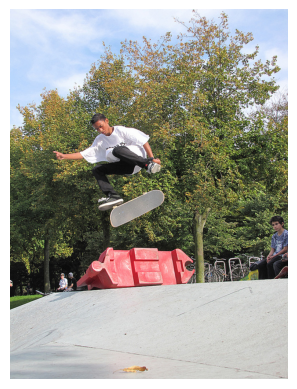

Image ID: 474054
Number of captions: 5
1. A man flying through the air while riding a skateboard.
2. A young man ridding a skateboard jumps a red object on a ramp in the park while others watch.
3. A COUPLE OF GUYS ENJOYING A SKATEBOARD PARK
4. A skater does a trick while jumping in the air.
5. A young man is doing a trick on a skateboard.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ann_id = np.random.choice(ids)
img_id = coco.anns[ann_id]['image_id']

img_info = coco.loadImgs(img_id)[0]

image_path = os.path.join(
    dataDir,
    dataType,
    img_info['file_name']
)

print(image_path)
print(os.path.exists(image_path))

image = Image.open(image_path)

plt.imshow(image)
plt.axis('off')
plt.show()

# Get caption annotations for the selected image
caption_ids = coco_caps.getAnnIds(imgIds=img_id)
captions = coco_caps.loadAnns(caption_ids)

print(f"Image ID: {img_id}")
print(f"Number of captions: {len(captions)}")

for i, annotation in enumerate(captions, 1):
    print(f"{i}. {annotation['caption']}")

## Step 3: What's to Come!

In this project, you will use the dataset of image-caption pairs to train a CNN-RNN model to automatically generate captions from images.  You'll learn more about how to design the architecture in the next notebook in the sequence (**1_Preliminaries.ipynb**).

![Image Captioning CNN-RNN model](images/encoder-decoder.png)